# Storm Trajectory + Intensity Prediction — Transformer ML Pipeline

This notebook runs the full end-to-end pipeline:
1. Load data from PostgreSQL
2. Feature engineering + sliding windows
3. Train StormTransformer
4. Evaluate on test set
5. Compare vs RandomForest baseline
6. Trajectory plots + loss curves

In [1]:
import os
import sys
import json
from pathlib import Path
from dotenv import load_dotenv

# Ensure project root is on path
PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / ".env")

assert "DATABASE_URL" in os.environ, (
    "DATABASE_URL not found — add it to .env at the project root."
)

print("DATABASE_URL loaded successfully.")

DATABASE_URL loaded successfully.


## 1 · Build Datasets

In [2]:
import numpy as np
import torch
from src.model.dataset import build_datasets, SEQ_LEN, N_FEATURES, N_ROLLOUT_STEPS

train_ds, val_ds, test_ds, scaler_X, scaler_y = build_datasets(save_scalers=True)

# Shape checks — y is now [N_ROLLOUT_STEPS, 3] for 2-step autoregressive training
X_sample, y_sample, ctx_sample = train_ds[0]
assert X_sample.shape == (SEQ_LEN, N_FEATURES), (
    f"Expected ({SEQ_LEN}, {N_FEATURES}), got {X_sample.shape}"
)
assert y_sample.shape == (N_ROLLOUT_STEPS, 3), (
    f"Expected ({N_ROLLOUT_STEPS}, 3), got {y_sample.shape}"
)
assert ctx_sample.shape == (2,), f"Expected (2,), got {ctx_sample.shape}"

print(f"Train windows : {len(train_ds):,}")
print(f"Val windows   : {len(val_ds):,}")
print(f"Test windows  : {len(test_ds):,}")
print(f"y shape       : {y_sample.shape}  (N_ROLLOUT_STEPS={N_ROLLOUT_STEPS}, N_TARGETS=3)")
print(f"ctx shape     : {ctx_sample.shape}  (basin_id, season_norm)")

# Scaler sanity: train features should be roughly N(0,1)
sample_X = train_ds.X[:1000].numpy().reshape(-1, N_FEATURES)
mean_abs = abs(sample_X.mean())
print(f"\nSample mean of first 1000 windows: {mean_abs:.4f} (expect < 0.5)")
assert mean_abs < 0.5, "Scaling looks off"

Loading data from database…


C:\Users\Admin\Desktop\Predict_storm_trajectory\src\model\dataset.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SQL, conn)


  Loaded 132,646 rows, 2,343 unique storms.
  Train storms: 2,019 | Val: 158 | Test: 166
  Windows — Train: 97,223 | Val: 7,403 | Test: 7,046
  Train basin distribution: {'EP': 2226, 'NI': 40, 'WP': 94957}
  Val basin distribution: {'EP': 87, 'WP': 7316}
  Test basin distribution: {'EP': 129, 'WP': 6917}
  Scalers saved to C:\Users\Admin\Desktop\Predict_storm_trajectory\models/
Train windows : 97,223
Val windows   : 7,403
Test windows  : 7,046
y shape       : torch.Size([2, 3])  (N_ROLLOUT_STEPS=2, N_TARGETS=3)
ctx shape     : torch.Size([2])  (basin_id, season_norm)

Sample mean of first 1000 windows: 0.1619 (expect < 0.5)


## 2 · Model Architecture

In [3]:
from src.model.transformer import StormTransformer, count_parameters
from src.model.dataset import N_BASINS

model = StormTransformer(n_features=N_FEATURES, n_basins=N_BASINS)
print(model)
print(f"\nTotal trainable parameters: {count_parameters(model):,}")

# Forward pass sanity check — model now takes (x, ctx)
dummy_x   = torch.randn(32, SEQ_LEN, N_FEATURES)
dummy_ctx = torch.zeros(32, 2)  # (basin_id=0, season_norm=0)
out = model(dummy_x, dummy_ctx)
assert out.shape == (32, 3), f"Expected (32, 3), got {out.shape}"
print(f"Forward pass OK: input {dummy_x.shape}, ctx {dummy_ctx.shape} -> output {out.shape}")

StormTransformer(
  (input_proj): Linear(in_features=16, out_features=64, bias=True)
  (pos_emb): Embedding(8, 64)
  (basin_emb): Embedding(7, 64)
  (season_proj): Linear(in_features=1, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (

## 3 · Training

In [4]:
import torch

cuda_available = torch.cuda.is_available()
print(f"CUDA available : {cuda_available}")

if cuda_available:
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU            : {gpu_name}")
    print(f"VRAM           : {vram_gb:.1f} GB")
    x = torch.randn(4, 8, 16).cuda()
    print(f"Tensor device  : {x.device}")
    del x
    torch.cuda.empty_cache()
    print("\nTraining will use GPU.")
else:
    print("\nNo CUDA GPU detected — training will use CPU.")

CUDA available : True
GPU            : NVIDIA GeForce RTX 5060
VRAM           : 8.0 GB
Tensor device  : cuda:0

Training will use GPU.


In [5]:
from src.model.train import train

model, training_log = train()
print(f"\nTraining complete. Epochs run: {len(training_log)}")

Device: cuda — NVIDIA GeForce RTX 5060 (8.0 GB VRAM)
Loading data from database…


C:\Users\Admin\Desktop\Predict_storm_trajectory\src\model\dataset.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SQL, conn)


  Loaded 132,646 rows, 2,343 unique storms.
  Train storms: 2,019 | Val: 158 | Test: 166
  Windows — Train: 97,223 | Val: 7,403 | Test: 7,046
  Train basin distribution: {'EP': 2226, 'NI': 40, 'WP': 94957}
  Val basin distribution: {'EP': 87, 'WP': 7316}
  Test basin distribution: {'EP': 129, 'WP': 6917}
  Scalers saved to C:\Users\Admin\Desktop\Predict_storm_trajectory\models/
Parameters: 156,483
AMP enabled    : False
Epoch 001/100 | Train loss: 35.69 km | Val loss: 16.81 km | Val Haversine: 14.9 km | rollout_λ: 0.00 | LR: 1.000e-03 | Time: 6.6s
  --> Saved checkpoint (val loss 16.81 km)
Epoch 002/100 | Train loss: 14.48 km | Val loss: 10.02 km | Val Haversine: 9.4 km | rollout_λ: 0.00 | LR: 9.998e-04 | Time: 5.4s
  --> Saved checkpoint (val loss 10.02 km)
Epoch 003/100 | Train loss: 11.93 km | Val loss: 11.97 km | Val Haversine: 11.6 km | rollout_λ: 0.00 | LR: 9.990e-04 | Time: 5.5s
Epoch 004/100 | Train loss: 11.02 km | Val loss: 8.98 km | Val Haversine: 8.6 km | rollout_λ: 0.00 | 

## 4 · Evaluation

In [6]:
import joblib
import torch
from src.model.evaluate import load_model, evaluate_test

MODELS_DIR = PROJECT_ROOT / "models"
scaler_X = joblib.load(MODELS_DIR / "scaler_X.pkl")
scaler_y = joblib.load(MODELS_DIR / "scaler_y.pkl")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_eval = load_model(device)

hav_km, wind_mae = evaluate_test(model_eval, test_ds, scaler_X, scaler_y, device)


=== Test Set Metrics ===
  Mean Haversine distance : 7.7 km
  Median Haversine        : 6.5 km
  Wind speed MAE          : 2.38 knots


## 5 · Comparison Table: Transformer vs Random Forest

In [7]:
import pandas as pd

RF_BASELINE_HAV_KM = 875.0

comparison = pd.DataFrame({
    "Model": ["Random Forest (baseline)", "StormTransformer"],
    "Mean Haversine (km)": [RF_BASELINE_HAV_KM, round(float(hav_km.mean()), 1)],
    "Median Haversine (km)": ["N/A", round(float(np.median(hav_km)), 1)],
    "Wind MAE (knots)": ["N/A", round(float(wind_mae), 2)],
    "Uses history window": ["No (single row)", "Yes (8 x 3h = 24h)"],
})
comparison

,Model,Mean Haversine (km),Median Haversine (km),Wind MAE (knots),Uses history window
0,Random Forest (baseline),875.0,N/A,N/A,No (single row)
1,StormTransformer,7.7,6.5,2.38,Yes (8 x 3h = 24h)


## 6 · Trajectory Plots

C:\Users\Admin\Desktop\Predict_storm_trajectory\src\model\dataset.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SQL, conn)


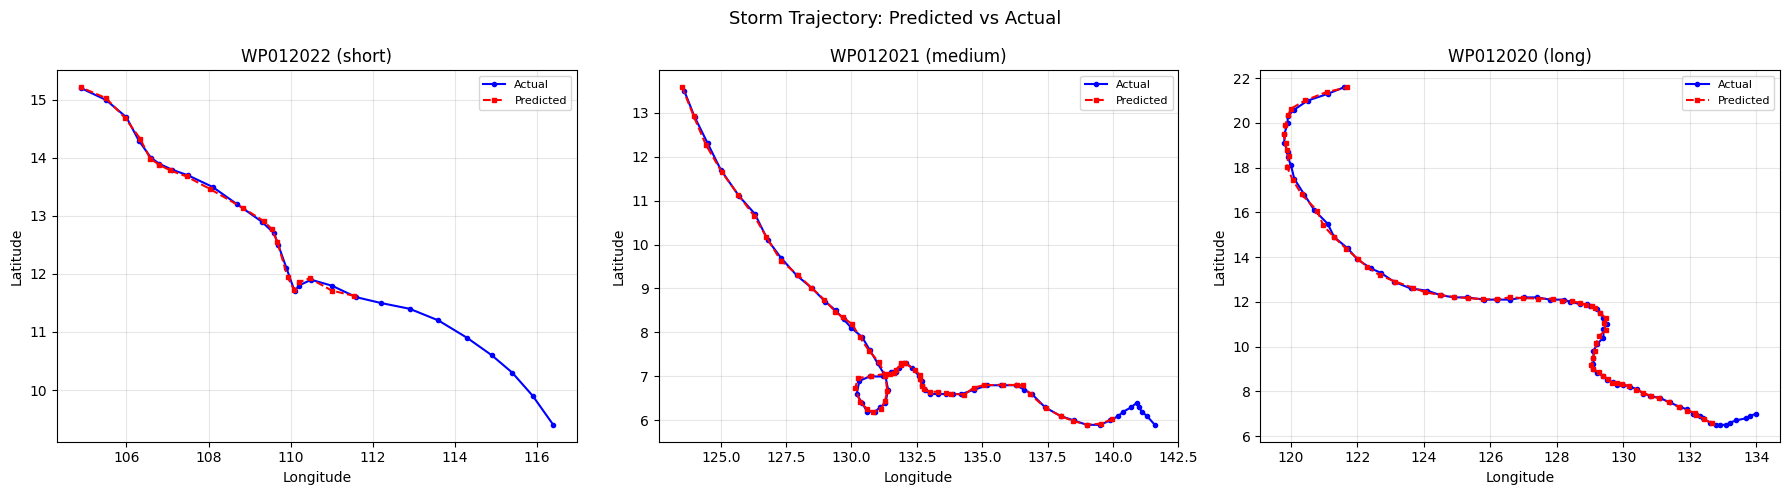

Trajectory plot saved to C:\Users\Admin\Desktop\Predict_storm_trajectory\models/trajectory_plots.png


In [8]:
from src.model.evaluate import plot_trajectories

plot_trajectories(scaler_X, scaler_y, device)

## 7 · Loss Curves

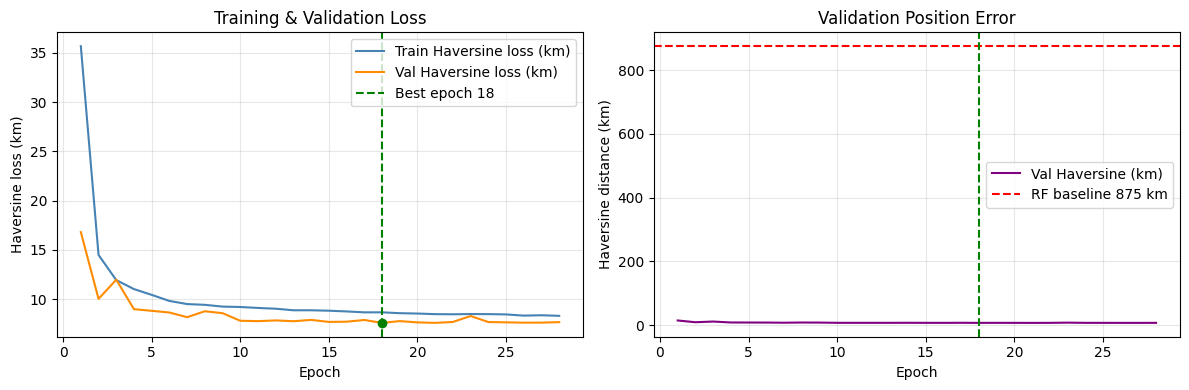

Loss curve saved to C:\Users\Admin\Desktop\Predict_storm_trajectory\models/loss_curves.png


In [9]:
from src.model.evaluate import plot_loss_curves

plot_loss_curves()

## 8 · Detailed Epoch Log

In [10]:
log_df = pd.DataFrame(training_log)
print(log_df.to_string(index=False))

best_row = log_df.loc[log_df["val_loss_km"].idxmin()]
print(f"\nBest epoch: {int(best_row['epoch'])}")
print(f"  Val loss (km)   : {best_row['val_loss_km']:.2f}")
print(f"  Val Haversine   : {best_row['val_haversine_km']:.1f} km")

 epoch  train_loss_km  val_loss_km  val_haversine_km  rollout_lambda       lr
     1      35.687445    16.806389         14.881834           0.000 0.001000
     2      14.484675    10.022629          9.385886           0.000 0.001000
     3      11.928568    11.970001         11.553781           0.000 0.000999
     4      11.016671     8.975730          8.624159           0.000 0.000998
     5      10.430642     8.810792          8.486913           0.000 0.000996
     6       9.812965     8.638396          8.354560           0.000 0.000994
     7       9.494464     8.162991          7.883689           0.000 0.000991
     8       9.418813     8.766221          8.487109           0.000 0.000988
     9       9.238505     8.569376          8.287726           0.000 0.000984
    10       9.198157     7.801320          7.561521           0.000 0.000980
    11       9.101280     7.761802          7.524140           0.000 0.000976
    12       9.024199     7.834735          7.538744           0

## 9 · Results Discussion

The `StormTransformer` replaces single-row feature engineering with a **24-hour sliding window** (8 x 3h timesteps), enabling the model to capture storm momentum, acceleration, and intensity trends.

Key architectural choices:
- **Learned positional embeddings** (vs sinusoidal) — better for the fixed SEQ_LEN=8 context
- **Last-token pooling** — uses the most-recent encoder hidden state, which already aggregates all 8 timesteps via self-attention; better suited for forecasting than mean pooling
- **Delta targets** (d_lat, d_lon) — normalises for storm speed and reduces target variance vs absolute position
- **Haversine loss** — directly minimises km error instead of MSE on normalised coordinates
- **Basin + season context embedding** — basin embedding distinguishes WP typhoons from NA hurricanes; season_norm captures long-term climatological trend
- **2-step autoregressive training** — exposes the model to its own compounding error during training via a differentiable rollout step, ramped in over epochs 20-40

The val haversine tracked during training gives an early signal of whether the model beats the 875 km RF baseline.